# Experiment 3 — Which time lag of price movement correlates with sentiment?

Experiments 1 & 2 tested only **same-day** and **next-day** returns: strong same-day
link (FinBERT r ≈ +0.23), nothing at t+1. Here we widen the horizon.

**Question:** For news sentiment on day *t*, which forward horizon of TSLA price
movement is most correlated — a week, two weeks, a month later?

**Definition:** "price movement *h* later" = **forward cumulative return**
`close(t+h) / close(t) − 1` over *h* trading days. We sweep
`h = 1, 3, 5 (≈1wk), 10 (≈2wk), 15, 21 (≈1mo), 42 (≈2mo), 63 (≈3mo)` and plot the
correlation vs. horizon for both FinBERT (exp 2 winner) and VADER.

*Caveat:* long horizons overlap heavily across consecutive days, so those p-values
are optimistic (autocorrelated observations) — read the long end as descriptive.

In [1]:
# 1. Setup
import sys
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "experiment_3" else Path.cwd()
EXP2_CSV = REPO_ROOT / "experiment_2" / "tsla_daily_finbert.csv"
sys.path.insert(0, str(REPO_ROOT))
print("Repo root:", REPO_ROOT)

Repo root: /Users/georgia/Documents/Trading/sentimental_trading


## 2. Load the FinBERT + VADER daily scores from experiment 2

In [2]:
# 2. Sentiment (already computed in experiment 2)
sent = pd.read_csv(EXP2_CSV, parse_dates=["date"])
sent = sent[["date", "finbert_sentiment", "vader_sentiment"]]
print(f"{len(sent)} sentiment days, {sent['date'].min().date()} -> {sent['date'].max().date()}")
sent.head()

565 sentiment days, 2024-01-02 -> 2026-04-08


,date,finbert_sentiment,vader_sentiment
0,2024-01-02,-0.223781,0.164387
1,2024-01-03,-0.015199,0.161350
2,2024-01-04,-0.153485,-0.007069
3,2024-01-05,-0.086602,0.084625
4,2024-01-08,-0.030544,0.086440


## 3. Fetch the full daily price series (through today)
We extend past the sentiment window so even the latest sentiment dates have complete forward windows out to ~3 months.

In [3]:
# 3. Daily bars via the existing get_bars generator, 2024-01-01 -> today
import get_bars as gb

end = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

def fetch(feed):
    params = {"timeframe": "1Day", "start": "2024-01-01T00:00:00Z", "end": end,
              "limit": 10000, "adjustment": "split", "feed": feed, "sort": "asc"}
    return list(gb.get_bars(params))

try:
    bars = fetch("sip"); feed_used = "sip"
except Exception as e:
    print("SIP failed:", repr(e), "-> IEX")
    bars = fetch("iex"); feed_used = "iex"

prices = pd.DataFrame(bars)
prices["date"] = pd.to_datetime(prices["t"], utc=True).dt.tz_localize(None).dt.normalize()
prices = prices.sort_values("date").reset_index(drop=True)
print(f"{len(prices)} daily bars via {feed_used}: {prices['date'].min().date()} -> {prices['date'].max().date()}")
prices[["date", "c"]].tail(3)

SIP failed: HTTPError('403 Client Error: Forbidden for url: https://data.alpaca.markets/v2/stocks/TSLA/bars?timeframe=1Day&start=2024-01-01T00%3A00%3A00Z&end=2026-07-22T00%3A05%3A08Z&limit=10000&adjustment=split&feed=sip&sort=asc') -> IEX


639 daily bars via iex: 2024-01-02 -> 2026-07-21


,date,c
636,2026-07-17,380.900
637,2026-07-20,369.665
638,2026-07-21,378.900


## 4. Forward cumulative returns at each horizon
Computed on the full contiguous trading-day series, so shifts respect the true sequence.

In [4]:
# 4. Forward returns
HORIZONS = [
    ("+1d", 1), ("+3d", 3), ("1 week (5d)", 5), ("2 weeks (10d)", 10),
    ("3 weeks (15d)", 15), ("1 month (21d)", 21), ("2 months (42d)", 42),
    ("3 months (63d)", 63),
]
for _, h in HORIZONS:
    prices[f"fwd_{h}"] = prices["c"].shift(-h) / prices["c"] - 1.0
prices["same_day"] = prices["c"].pct_change()  # contemporaneous reference
print("Forward-return columns:", [f"fwd_{h}" for _, h in HORIZONS])
prices[["date", "c", "fwd_5", "fwd_21", "fwd_63"]].head()

Forward-return columns: ['fwd_1', 'fwd_3', 'fwd_5', 'fwd_10', 'fwd_15', 'fwd_21', 'fwd_42', 'fwd_63']


,date,c,fwd_5,fwd_21,fwd_63
0,2024-01-02,248.48,-0.054733,-0.240140,-0.322199
1,2024-01-03,238.44,-0.019082,-0.212255,-0.282084
2,2024-01-04,237.94,-0.045011,-0.239094,-0.307136
3,2024-01-05,237.48,-0.078533,-0.220692,-0.271560
4,2024-01-08,240.42,-0.085059,-0.219657,-0.263955


## 5. Merge sentiment with forward returns

In [5]:
# 5. Inner-join sentiment onto the price/forward-return table
df = prices.merge(sent, on="date", how="inner").sort_values("date").reset_index(drop=True)
print(f"{len(df)} rows with sentiment + forward returns")
# how many rows have a valid 3-month forward window?
print("non-NaN fwd_63:", int(df["fwd_63"].notna().sum()), "/", len(df))
df[["date", "c", "finbert_sentiment", "fwd_5", "fwd_21"]].head()

565 rows with sentiment + forward returns
non-NaN fwd_63: 565 / 565


,date,c,finbert_sentiment,fwd_5,fwd_21
0,2024-01-02,248.48,-0.223781,-0.054733,-0.240140
1,2024-01-03,238.44,-0.015199,-0.019082,-0.212255
2,2024-01-04,237.94,-0.153485,-0.045011,-0.239094
3,2024-01-05,237.48,-0.086602,-0.078533,-0.220692
4,2024-01-08,240.42,-0.030544,-0.085059,-0.219657


## 6. Correlation at each horizon (FinBERT and VADER)

In [6]:
# 6. Correlate sentiment(t) vs forward return at each horizon
def corr(x, y):
    m = x.notna() & y.notna()
    if m.sum() < 10:
        return m.sum(), np.nan, np.nan, np.nan, np.nan
    pr, pp = stats.pearsonr(x[m], y[m])
    sr, sp = stats.spearmanr(x[m], y[m])
    return int(m.sum()), pr, pp, sr, sp

rows = []
for model, col in [("FinBERT", "finbert_sentiment"), ("VADER", "vader_sentiment")]:
    # same-day reference
    n, pr, pp, sr, sp = corr(df[col], df["same_day"])
    rows.append({"model": model, "horizon": "same-day (0d)", "days": 0, "n": n,
                 "pearson_r": pr, "pearson_p": pp, "spearman_r": sr, "spearman_p": sp})
    for label, h in HORIZONS:
        n, pr, pp, sr, sp = corr(df[col], df[f"fwd_{h}"])
        rows.append({"model": model, "horizon": label, "days": h, "n": n,
                     "pearson_r": pr, "pearson_p": pp, "spearman_r": sr, "spearman_p": sp})

table = pd.DataFrame(rows)
table.to_csv("tsla_horizon_correlations.csv", index=False)
table.round(4)

,model,horizon,days,n,pearson_r,pearson_p,spearman_r,spearman_p
0,FinBERT,same-day (0d),0,564,0.2267,0.0000,0.2278,0.0000
1,FinBERT,+1d,1,565,-0.0364,0.3874,-0.0314,0.4563
2,FinBERT,+3d,3,565,-0.0341,0.4188,-0.0540,0.1997
3,FinBERT,1 week (5d),5,565,0.0158,0.7071,-0.0068,0.8720
4,FinBERT,2 weeks (10d),10,565,-0.0267,0.5271,-0.0260,0.5371
5,FinBERT,3 weeks (15d),15,565,-0.0328,0.4369,-0.0594,0.1584
6,FinBERT,1 month (21d),21,565,-0.0257,0.5418,-0.0606,0.1504
7,FinBERT,2 months (42d),42,565,-0.0267,0.5264,-0.0593,0.1593
8,FinBERT,3 months (63d),63,565,-0.0461,0.2745,-0.0801,0.0570
9,VADER,same-day (0d),0,564,0.1201,0.0043,0.1239,0.0032


## 7. Plots

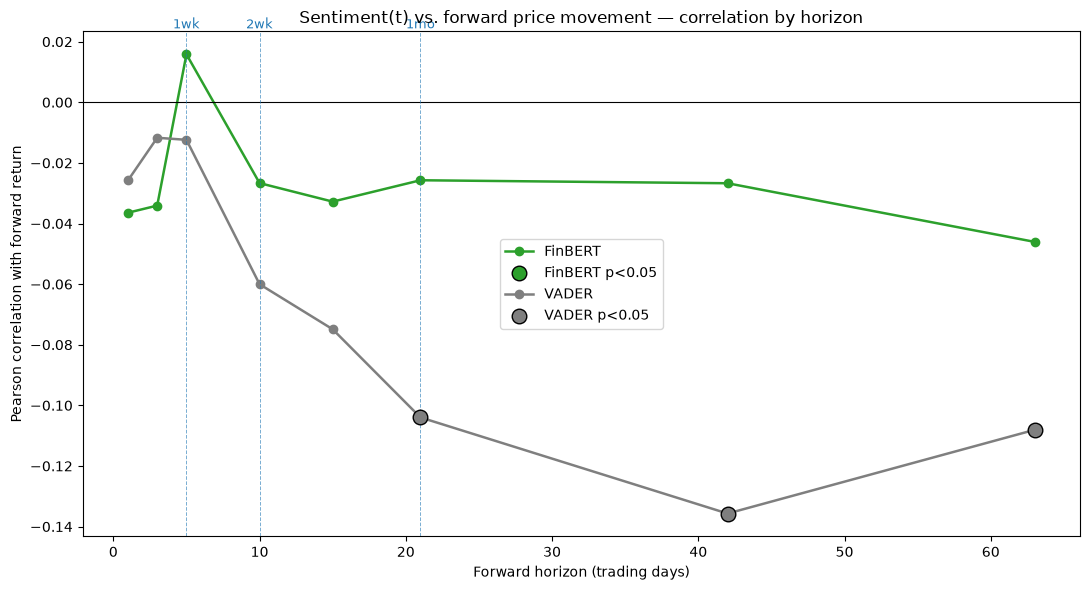

In [7]:
# 7a. Correlation vs horizon (the key chart)
fig, ax = plt.subplots(figsize=(11, 6))
for model, color in [("FinBERT", "tab:green"), ("VADER", "tab:gray")]:
    sub = table[(table["model"] == model) & (table["days"] > 0)].sort_values("days")
    ax.plot(sub["days"], sub["pearson_r"], "-o", color=color, label=model, lw=1.8)
    # fill significant points
    sig = sub[sub["pearson_p"] < 0.05]
    ax.scatter(sig["days"], sig["pearson_r"], s=110, facecolors=color,
               edgecolors="black", zorder=5, label=f"{model} p<0.05")
ax.axhline(0, color="black", lw=0.8)
for d, lab in [(5, "1wk"), (10, "2wk"), (21, "1mo")]:
    ax.axvline(d, color="tab:blue", ls="--", lw=0.7, alpha=0.6)
    ax.text(d, ax.get_ylim()[1], lab, color="tab:blue", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Forward horizon (trading days)")
ax.set_ylabel("Pearson correlation with forward return")
ax.set_title("Sentiment(t) vs. forward price movement — correlation by horizon")
ax.legend()
plt.tight_layout()
plt.show()

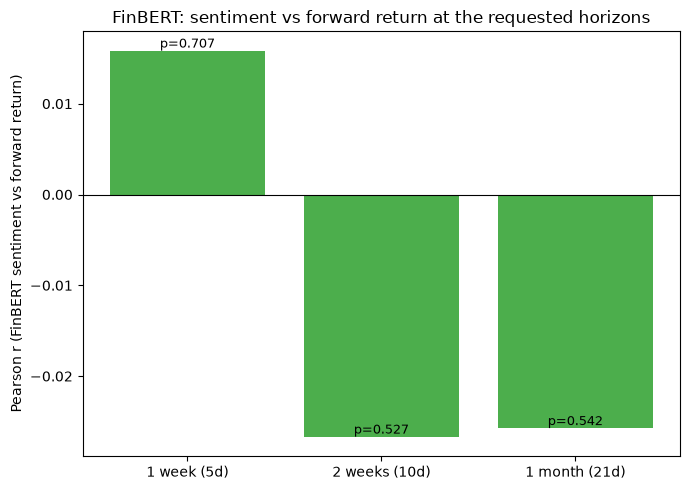

In [8]:
# 7b. The three requested horizons, FinBERT
req = table[(table["model"] == "FinBERT") & (table["horizon"].isin(
    ["1 week (5d)", "2 weeks (10d)", "1 month (21d)"]))]
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(req["horizon"], req["pearson_r"], color="tab:green", alpha=0.85)
for b, p in zip(bars, req["pearson_p"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f"p={p:.3f}", ha="center", va="bottom", fontsize=9)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Pearson r (FinBERT sentiment vs forward return)")
ax.set_title("FinBERT: sentiment vs forward return at the requested horizons")
plt.tight_layout()
plt.show()

## 8. Verdict — which lag is most correlated?

In [9]:
# 8. Find the strongest horizon for FinBERT
fb = table[(table["model"] == "FinBERT") & (table["days"] > 0)].copy()
fb["abs_r"] = fb["pearson_r"].abs()
best = fb.loc[fb["abs_r"].idxmax()]

print("QUESTION: which forward horizon of price movement correlates most with sentiment(t)?")
print("=" * 76)
print(f"{'horizon':<18}{'Pearson r':>12}{'p-value':>12}{'  significant?':>16}")
print("-" * 76)
for _, r in fb.sort_values("days").iterrows():
    sig = "yes" if r["pearson_p"] < 0.05 else "no"
    print(f"{r['horizon']:<18}{r['pearson_r']:>+12.3f}{r['pearson_p']:>12.4f}{sig:>16}")

print("\n" + "=" * 76)
direction = "positive (momentum — good news -> further gains)" if best["pearson_r"] > 0 \
            else "negative (mean-reversion — good news -> later pullback)"
print(f"STRONGEST horizon (FinBERT): {best['horizon']}  "
      f"(r={best['pearson_r']:+.3f}, p={best['pearson_p']:.4f})")
print(f"Direction: {direction}")

sd = table[(table["model"] == "FinBERT") & (table["horizon"] == "same-day (0d)")].iloc[0]
print(f"\nReference — same-day contemporaneous: r={sd['pearson_r']:+.3f} (p={sd['pearson_p']:.4f})")
print("Saved -> tsla_horizon_correlations.csv")

QUESTION: which forward horizon of price movement correlates most with sentiment(t)?
horizon              Pearson r     p-value    significant?
----------------------------------------------------------------------------
+1d                     -0.036      0.3874              no
+3d                     -0.034      0.4188              no
1 week (5d)             +0.016      0.7071              no
2 weeks (10d)           -0.027      0.5271              no
3 weeks (15d)           -0.033      0.4369              no
1 month (21d)           -0.026      0.5418              no
2 months (42d)          -0.027      0.5264              no
3 months (63d)          -0.046      0.2745              no

STRONGEST horizon (FinBERT): 3 months (63d)  (r=-0.046, p=0.2745)
Direction: negative (mean-reversion — good news -> later pullback)

Reference — same-day contemporaneous: r=+0.227 (p=0.0000)
Saved -> tsla_horizon_correlations.csv


### How to read this

- The **same-day** bar is the reaction baseline (news moving with price).
- A rising curve into **1 week / 1 month** would suggest sentiment **leads** price
  (momentum / drift); a curve that goes **negative** at longer horizons suggests
  **mean-reversion** (initial sentiment move later unwinds).
- Remember the autocorrelation caveat: overlapping multi-day windows make long-horizon
  p-values optimistic. A consistent *shape* across horizons and across both models is
  more trustworthy than any single significant point.